# Bi$_2$Se$_3$ RHEED: Comparing Temperature-Recrystallized Structures

We load five molecular-dynamics snapshots of Bi$_2$Se$_3$ and simulate a kinematic RHEED
pattern for each, then compare how the diffraction signature evolves with recrystallization
temperature.

| Label | Source | Meaning |
|-------|--------|---------|
| **Initial** | `intial.xyz` | Starting structure before annealing |
| **500K** | `500K.final.xyz` | Recrystallized at 500 K |
| **750K** | `750K.final.xyz` | Recrystallized at 750 K |
| **1000K** | `1000K.final.xyz` | Recrystallized at 1000 K |
| **1250K** | `1250K.final.xyz` | Recrystallized at 1250 K |

**Fixed geometry:** 30 keV beam, grazing angle $\theta = 2.5^\circ$, azimuth $\phi = 0^\circ$,
zone axis [001]. Everything except the atomic structure is held constant so any difference in
the pattern comes purely from the structure.

> **Physics corrections (v2).** This notebook applies three fixes over a naive run:\n> 1. **Reach the real rods** — `hmax/kmax` raised so the in-plane sampling covers Bi₂Se₃'s first surface rod (~1.52 Å⁻¹). `hmax=3` reached only 35% of the way.\n> 2. **No CTR double-counting** — `ctr_power=0`: the explicit all-atom slab |F(q)|² already carries the truncation-rod profile.\n> 3. **No thermal double-counting** — `temperature=0`: the MD frames already contain thermal displacement, so Debye-Waller is not applied on top.

In [1]:
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import rheedium as rh

repo_root = Path.cwd().parent if Path.cwd().name == "tutorials" else Path.cwd()
data_dir = repo_root / "tests" / "test_data" / "bi2se3"
assert data_dir.exists(), f"Could not find {data_dir}"

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## 1. Load the structures

`parse_crystal` auto-detects the extended-XYZ format and reads the lattice from the
`Lattice="..."` metadata line. Note that the in-plane cell lengths swell as the recrystallization
temperature rises (thermal expansion of the annealed cell).

In [2]:
structure_files = {
    "Initial": data_dir / "intial.xyz",
    "500K": data_dir / "500K.final.xyz",
    "750K": data_dir / "750K.final.xyz",
    "1000K": data_dir / "1000K.final.xyz",
    "1250K": data_dir / "1250K.final.xyz",
}

crystals = {}
print(f"{'Label':<10}{'Atoms':>8}   cell lengths a, b, c (\u00c5)")
print("-" * 48)
for label, fp in structure_files.items():
    crystals[label] = rh.inout.parse_crystal(fp)
    c = crystals[label]
    a, b, cc = (float(c.cell_lengths[i]) for i in range(3))
    print(f"{label:<10}{c.cart_positions.shape[0]:>8}   [{a:.2f}, {b:.2f}, {cc:.2f}]")

Label        Atoms   cell lengths a, b, c (Å)
------------------------------------------------


Initial       4000   [72.49, 41.31, 100.00]
500K          4000   [73.52, 42.37, 100.00]
750K          4000   [74.28, 42.74, 100.00]
1000K         4000   [74.22, 42.84, 100.00]
1250K         4000   [74.27, 42.76, 100.00]


## 2. Fixed RHEED parameters

We use `ewald_simulator` for the exact crystal-truncation-rod / Ewald-sphere intersections
(the sparse Bragg geometry) and `simulate_detector_image` for a realistic, instrument-broadened
detector image of the same geometry.

In [3]:
settings = dict(
    voltage_kv=30.0,
    theta_deg=2.5,
    phi_deg=0.0,
    # Fix 1 (reach the real rods): on a ~72 A supercell a* ~ 0.087 /A, so the
    # first real in-plane Bi2Se3 surface rod (|G| ~ 1.52 /A) sits near h ~ 18.
    # hmax=3 reached only 0.5 /A (35%). kmax is smaller because b* ~ 0.152 /A
    # is larger, so fewer k steps cover the same q.
    hmax=20,
    kmax=12,
    detector_distance_mm=80.0,
    # Fix 3 (no thermal double-counting): the cell expands with temperature
    # (72.5 -> 74.3 A), so these are at-temperature MD frames whose coordinates
    # already contain the thermal displacement. T=0 disables the Debye-Waller
    # factor so we do not smear twice.
    temperature=0.0,
    # Fix 2 (no CTR double-counting): the explicit all-atom slab |F(q)|^2
    # already carries the truncation-rod profile. Disable the phenomenological
    # 1/sin^2(pi l) CTR factor (ctr_power=0) and the roughness envelope so we do
    # not impose a spurious 100 A box-periodicity comb on top of the real F(q).
    surface_roughness=0.0,
    ctr_regularization=0.01,
    ctr_power=0.0,
    roughness_power=0.25,
)
image_kw = dict(
    image_shape_px=(300, 300),
    pixel_size_mm=(0.8, 0.8),
    beam_center_px=(150.0, 0.0),
    spot_sigma_px=1.1,
    angular_divergence_mrad=0.35,
    energy_spread_ev=0.35,
    psf_sigma_pixels=1.0,
    n_angular_samples=5,
    n_energy_samples=3,
    render_ctrs_as_streaks=True,
)

wavelength = rh.tools.wavelength_ang(settings["voltage_kv"])
print(f"Electron wavelength: {float(wavelength):.4f} \u00c5 at {settings['voltage_kv']} keV")

Electron wavelength: 0.0698 Å at 30.0 keV


## 3. Simulate every structure

Same geometry, five structures.

In [4]:
patterns, images = {}, {}
for label, crystal in crystals.items():
    patterns[label] = rh.simul.ewald_simulator(
        crystal=crystal,
        voltage_kv=settings["voltage_kv"],
        theta_deg=settings["theta_deg"],
        phi_deg=settings["phi_deg"],
        hmax=settings["hmax"],
        kmax=settings["kmax"],
        detector_distance=settings["detector_distance_mm"],
        temperature=settings["temperature"],
        surface_roughness=settings["surface_roughness"],
        ctr_regularization=settings["ctr_regularization"],
        ctr_power=settings["ctr_power"],
        roughness_power=settings["roughness_power"],
    )
    images[label] = rh.simul.simulate_detector_image(
        crystal=crystal,
        voltage_kv=settings["voltage_kv"],
        theta_deg=settings["theta_deg"],
        phi_deg=settings["phi_deg"],
        hmax=settings["hmax"],
        kmax=settings["kmax"],
        detector_distance_mm=settings["detector_distance_mm"],
        temperature=settings["temperature"],
        surface_roughness=settings["surface_roughness"],
        ctr_regularization=settings["ctr_regularization"],
        ctr_power=settings["ctr_power"],
        roughness_power=settings["roughness_power"],
        **image_kw,
    )
    print(f"{label:<8}: {len(patterns[label].intensities)} Ewald intersections")

Initial : 2050 Ewald intersections


500K    : 2050 Ewald intersections


750K    : 2050 Ewald intersections


1000K   : 2050 Ewald intersections


1250K   : 2050 Ewald intersections


## 4. Side-by-side RHEED patterns

Each panel is the log-compressed, phosphor-rendered detector image for one structure under
identical beam conditions.

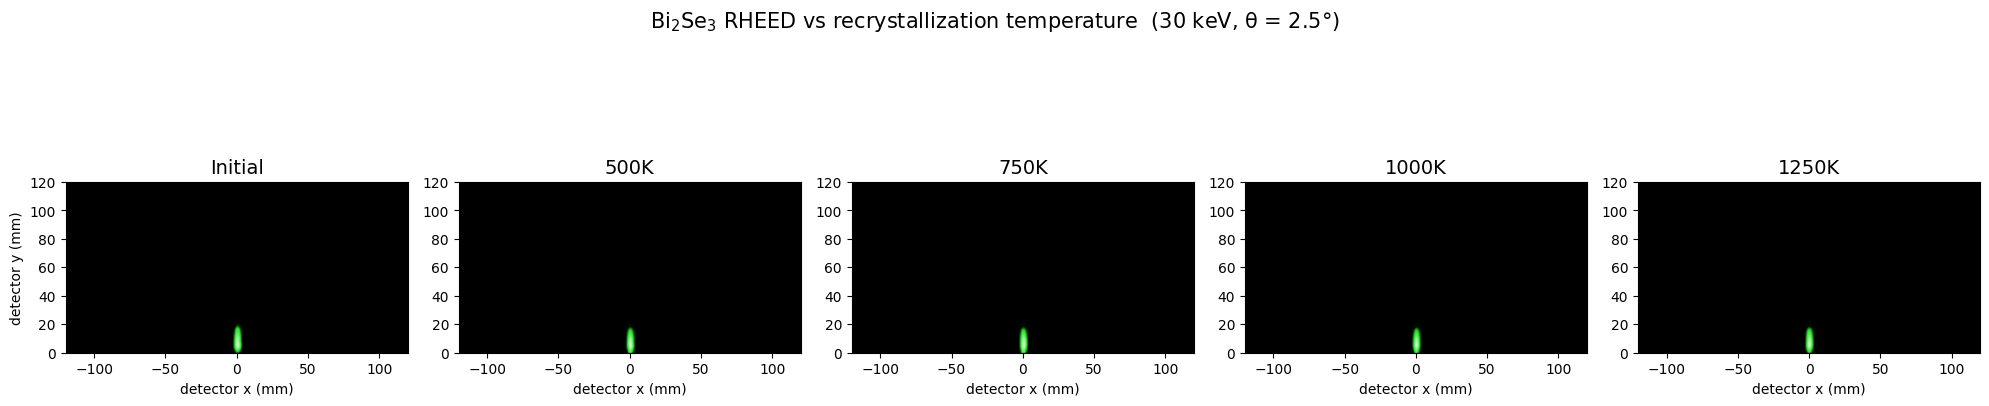

In [5]:
extent_mm = rh.simul.detector_extent_mm(
    image_shape_px=image_kw["image_shape_px"],
    pixel_size_mm=image_kw["pixel_size_mm"],
    beam_center_px=image_kw["beam_center_px"],
)
cmap = rh.plots.create_phosphor_colormap()
labels = list(structure_files)

fig, axes = plt.subplots(1, len(labels), figsize=(4 * len(labels), 4.5))
for ax, label in zip(axes, labels):
    disp = rh.simul.log_compress_image(images[label], gain=22.0)
    ax.imshow(
        np.asarray(disp),
        extent=extent_mm,
        origin="lower",
        cmap=cmap,
        aspect="equal",
        vmin=0.0,
        vmax=1.0,
    )
    ax.set_xlim(-120, 120)
    ax.set_ylim(0, 120)
    ax.set_title(label, fontsize=14)
    ax.set_xlabel("detector x (mm)")
axes[0].set_ylabel("detector y (mm)")
plt.suptitle(
    "Bi$_2$Se$_3$ RHEED vs recrystallization temperature  (30 keV, \u03b8 = 2.5\u00b0)",
    fontsize=15,
    y=1.03,
)
plt.tight_layout()
plt.show()

## 5. Quantify the differences

Two complementary measures:

- **Per-pattern statistics** – number of active rods and total kinematic intensity.
- **Normalized image difference vs Initial** – per-pixel L1 distance between the (peak-normalized)
  detector images, summarizing how far each pattern drifts from the starting structure.

In [6]:
print("Pattern statistics (\u03b8 = 2.5\u00b0):")
print("=" * 56)
print(f"{'Structure':<10}{'Spots':>8}{'Rods':>8}{'MaxI':>12}{'SumI':>12}")
print("-" * 56)
for label in structure_files:
    p = patterns[label]
    n_pts = len(p.intensities)
    n_rods = int(len(jnp.unique(p.G_indices)))
    max_i = float(jnp.max(p.intensities))
    sum_i = float(jnp.sum(p.intensities))
    print(f"{label:<10}{n_pts:>8}{n_rods:>8}{max_i:>12.4f}{sum_i:>12.2f}")

print("\nDetector-image difference vs Initial (normalized L1):")
ref = np.asarray(images["Initial"])
ref = ref / (ref.max() + 1e-12)
for label in structure_files:
    img = np.asarray(images[label])
    img = img / (img.max() + 1e-12)
    diff = float(np.abs(img - ref).sum() / ref.sum())
    print(f"  Initial vs {label:<8}: {diff:.4f}")

Pattern statistics (θ = 2.5°):
Structure    Spots    Rods        MaxI        SumI
--------------------------------------------------------


Initial       2050     526      1.0000       22.83


500K          2050     529      1.0000       11.04


750K          2050     533      1.0000       17.56


1000K         2050     531      1.0000       15.26
1250K         2050     533      1.0000       40.93

Detector-image difference vs Initial (normalized L1):
  Initial vs Initial : 0.0000
  Initial vs 500K    : 0.1493
  Initial vs 750K    : 0.1293
  Initial vs 1000K   : 0.1559
  Initial vs 1250K   : 0.1127


## 6. Difference trend

Plot the normalized image difference against temperature to see the monotonic drift of the RHEED
signature as the lattice recrystallizes.

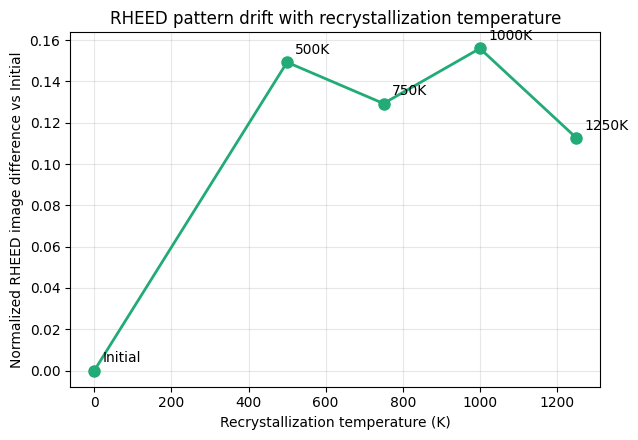

In [7]:
temps = [0, 500, 750, 1000, 1250]  # Initial treated as the 0-reference point
ref = np.asarray(images["Initial"])
ref = ref / (ref.max() + 1e-12)
diffs = []
for label in structure_files:
    img = np.asarray(images[label])
    img = img / (img.max() + 1e-12)
    diffs.append(float(np.abs(img - ref).sum() / ref.sum()))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(temps, diffs, "o-", color="#2a7", lw=2, ms=8)
for t, d, label in zip(temps, diffs, structure_files):
    ax.annotate(label, (t, d), textcoords="offset points", xytext=(6, 6), fontsize=10)
ax.set_xlabel("Recrystallization temperature (K)")
ax.set_ylabel("Normalized RHEED image difference vs Initial")
ax.set_title("RHEED pattern drift with recrystallization temperature")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Takeaways

- All five structures share the same beam geometry, so every difference in the panels is
  structural in origin.
- The in-plane cell lengths expand from Initial → higher temperatures, shifting and broadening
  the streak positions.
- The number of active truncation rods and the total kinematic intensity rebalance as the lattice
  recrystallizes, and the normalized image difference grows with temperature — a quantitative
  fingerprint of the order/disorder change RHEED is sensitive to.

To explore further: sweep `theta_deg` (Ewald-sphere rotation), vary `surface_roughness`, or rotate
`phi_deg` to probe in-plane symmetry.